# Week 02: Descriptive Statistics in Python

**Course:** MATH7810 Python for Data Science (AY2026/27)

## GitHub Codespaces setup
1. Open **your existing fork** of the course labs repo.
2. On github.com, click **Sync fork** if new week files were added.
3. Open your **previous Codespace** (**Code → Codespaces** → click the existing one). Create a new Codespace only if none remains in the list.
4. If this notebook (or other new files) still do not appear in the file tree: in the Codespace **terminal** run `git pull`, then refresh the file list.
5. Open this notebook. When asked to **Select Kernel**: choose **Python Environments** → **Python 3.12.x** whose path looks like `/usr/local/.../python`. Then run cells with **Shift+Enter** / the run button.
6. When you finish: **Commit + Push**, then **Stop** the Codespace.


## Learning goals
- Compute centre (mean, median) and spread (sample SD, IQR)
- Make a **bar chart** for a categorical variable (frequencies)
- Build a five-number summary and relate it to a boxplot
- Make a histogram and **side-by-side** graphs (links to Chapter 1)
- Compute Pearson correlation $r$ and read a scatterplot


In [1]:
# Purpose: load tools for numerical summaries and plots
import numpy as np   #alias for numpy
import matplotlib.pyplot as plt #alias for matplotlib.pyplot

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.12/site-packages/traitlets/traitlets.py", line 652, in get
    value = obj._trait_values[self.name]
            ~~~~~~~~~~~~~~~~~^^^^^^^^^^^
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 566, in _log_error
    f.result()
  File "/home/vscode/.local/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 347, in dispatch_control
    async with self._control_lock:
               ^^^^^^^^^^^^^^^^^^
  File "/home/vscode/.local/lib/python3.12/site-packages/traitlets/traitlets.py", line 705, in __get__
    return self.get(obj, cls)  # type:ignore[return-value]
           ^^^^^^^^^^^^^^^^^^
  File "/home/vscode/.local/lib/python3.12/site-packages/traitlets/traitlets.py", line 669,

### One-variable summaries — centre and spread

We store numerical observations in a NumPy array only so we can compute Chapter 1 summaries quickly.


In [2]:
# Purpose: mean, median, and sample SD (ddof=1 matches the sample formula in Chapter 1)
# Example data: customer wait times in minutes
wait = np.array([
    4.2, 5.1, 3.8, 6.0, 7.5, 5.4, 4.9, 8.1, 3.2, 5.8,
    6.3, 4.5, 9.0, 5.0, 4.7, 6.8, 7.2, 3.9, 5.6, 4.1,
    8.4, 5.3, 6.1, 4.8, 7.0, 5.9, 3.5, 6.5, 4.4, 5.2,
    7.8, 4.6, 5.7, 6.2, 4.0, 8.7, 5.5, 3.7, 6.7, 4.3,
])
print('mean:', wait.mean())
print('median:', np.median(wait))
print('std (sample): %.4f' % wait.std(ddof=1))

# %.4f means "insert a float with 4 digits after the decimal"
# The % after the string plugs wait.std(...) into that placeholder, so the result is already one finished string 
# print does not need a comma (unlike the mean/median rows above,
# which pass two separate arguments: a label and a number).

mean: 5.635
median: 5.45
std (sample): 1.5014


### Bar chart (categorical variable)

For a **categorical** variable, a bar chart shows the **frequency** (or count) in each category. Unlike a histogram, the bars are separated and the horizontal axis is category labels, not a numeric scale.


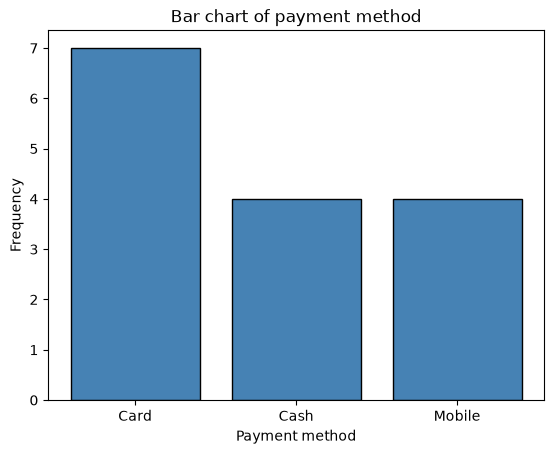

Card: 7
Cash: 4
Mobile: 4


In [3]:
# Purpose: bar chart of frequencies for a categorical variable
payment = ['Cash', 'Card', 'Card', 'Mobile', 'Card', 'Cash', 'Mobile', 'Card',
           'Cash', 'Card', 'Mobile', 'Card', 'Cash', 'Card', 'Mobile']

# np.unique finds the distinct category labels (sorted)
# return_counts=True also returns how many times each label appears
# unpack into two arrays: categories = labels, counts = frequencies

categories, counts = np.unique(payment, return_counts=True)

plt.bar(categories, counts, color='steelblue', edgecolor='black')  # one bar per category
plt.xlabel('Payment method')
plt.ylabel('Frequency')
plt.title('Bar chart of payment method')
plt.show()

# zip pairs each category with its count: ('Card', 7), ('Cash', 4), ...
# f'{cat}: {n}' inserts those values into the printed string
for cat, n in zip(categories, counts):
    print(f'{cat}: {n}')

### Histogram (quantitative variable)

A histogram shows the **shape** of a quantitative variable (bell-shaped, skew, gaps).


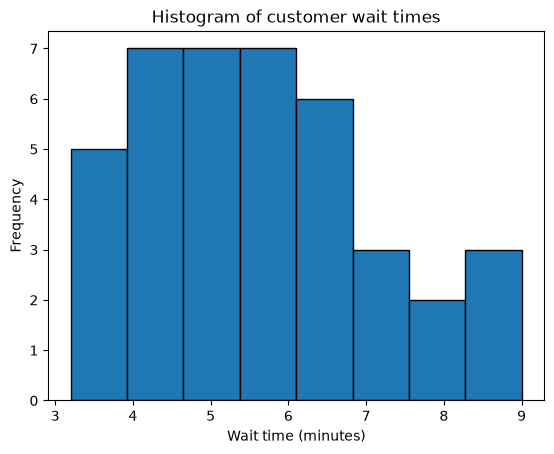

In [4]:
# Purpose: histogram of wait times (shape of one quantitative variable)
plt.hist(wait, bins=8, edgecolor='black')
plt.xlabel('Wait time (minutes)')
plt.ylabel('Frequency')
plt.title('Histogram of customer wait times')
plt.show()

### Five-number summary, IQR, and inner fences

These link directly to Chapter 1 numerical descriptive statistics and to reading a boxplot.


In [5]:
# Purpose: five-number summary for household income (thousands of dollars)
# 'weibull' : NumPy’s chosen interpolation method for percentiles; this method makes the output match the lecture notes calculation

income = np.array([75, 69, 84, 112, 74, 104, 81, 90, 94, 144, 79, 98])

minimum = np.min(income)
q1 = np.percentile(income, 25, method='weibull')
median = np.median(income)
q3 = np.percentile(income, 75, method='weibull')
maximum = np.max(income)

print('Minimum:', minimum)
print('Q1:', q1)
print('Median:', median)
print('Q3:', q3)
print('Maximum:', maximum)


Minimum: 69
Q1: 76.0
Median: 87.0
Q3: 102.5
Maximum: 144


In [6]:
# Purpose: IQR and inner fences (same rules as in the Chapter 1 slides)
IQR = q3 - q1
lowerfence = q1 - 1.5 * IQR
upperfence = q3 + 1.5 * IQR
print('IQR:', IQR)
print('lowerfence:', lowerfence)
print('upperfence:', upperfence)


IQR: 26.5
lowerfence: 36.25
upperfence: 142.25


### More measures of dispersion

Range / variance / SD / CV are Chapter 1 ideas; here we only compute them.


In [ ]:
# Purpose: dispersion measures on a simple numeric sample (use sample formulas: ddof=1)
data2 = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
mean2 = np.mean(data2)
variance = np.var(data2, ddof=1)
std_deviation = np.std(data2, ddof=1)
cv = std_deviation / mean2

print('Mean:', mean2)
print('Sample variance: %.4f' % variance)
print('Sample SD: %.4f' % std_deviation)
print('Coefficient of variation: %.4f' % cv)

### Boxplot and side-by-side graphs

In Chapter 1, **side-by-side** graphs compare a quantitative variable across groups.
In a standard boxplot, whiskers extend to the **most extreme non-outlier** points within the inner fences.


In [ ]:
# Purpose: side-by-side boxplots for two groups (compare centre, spread, skew, outliers)
np.random.seed(43)
group1 = np.random.lognormal(mean=3, sigma=1, size=100)  # right-skewed
group2 = np.random.normal(loc=25, scale=5, size=100)     # roughly symmetric

plt.boxplot(
    [group1, group2],  # data: one boxplot per group, drawn side by side
    tick_labels=['Group 1', 'Group 2'],  # x-axis tick labels under each box
    patch_artist=True,  # fill the boxes with colour (needed for facecolor below)
    boxprops=dict(facecolor='lightblue', color='blue'),  # box fill and border colour
    medianprops=dict(color='red'),  # colour of the median line inside each box
    whiskerprops=dict(color='blue'),  # colour of the whisker lines
    capprops=dict(color='blue'),  # colour of the caps at the ends of the whiskers
)
plt.title('Boxplot comparison of two groups')
plt.ylabel('Values')
plt.xlabel('Groups')
plt.show()

def print_stats(data, group_name):
    med = np.median(data)
    q1_ = np.percentile(data, 25)
    q3_ = np.percentile(data, 75)
    print(f"{group_name}: median={med:.2f}, IQR={q3_ - q1_:.2f}")

print_stats(group1, 'Group 1 (right-skewed)')
print_stats(group2, 'Group 2 (symmetric)')

In [ ]:
# print the raw data of group1 and group2
group1.sort()
group2.sort()

print(group1)
print(group2)

In [ ]:
# Purpose: side-by-side histograms with a shared bin width (same comparison idea as Chapter 1)
data_min = min(np.min(group1), np.min(group2))
data_max = max(np.max(group1), np.max(group2))
bin_width = 5
bins = np.arange(data_min, data_max + bin_width, bin_width)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)  # 1 row, 2 panels; shared y-axis for fair frequency comparison
ax1.hist(group1, bins=bins, color='lightblue', edgecolor='blue', alpha=0.7)  # left panel: histogram of group1
ax1.set_title('Group 1 (right-skewed)')  # title for the left panel
ax1.set_xlabel('Values')  # x-axis label for the left panel
ax1.set_ylabel('Frequency')  # y-axis label (shared scale with the right panel)

ax2.hist(group2, bins=bins, color='lightgreen', edgecolor='green', alpha=0.7)  # right panel: histogram of group2 (same bins)
ax2.set_title('Group 2 (symmetric)')  # title for the right panel
ax2.set_xlabel('Values')  # x-axis label for the right panel

plt.tight_layout()  # reduce overlapping titles/labels
plt.show()  # display the figure


### Correlation (two numerical variables)

Pearson $r$ measures **linear** association. A scatterplot shows the pattern; $r$ summarizes strength/direction (not causation).


In [ ]:
# Purpose: Pearson r and a scatterplot for two numerical variables
time_on_page = np.array([30, 45, 20, 60, 50, 80, 35, 90, 40, 70], dtype=float)
order_value = np.array([25, 40, 18, 55, 48, 70, 30, 85, 35, 60], dtype=float)
r = np.corrcoef(time_on_page, order_value)[0, 1]
print('r =', round(r, 3))

plt.scatter(time_on_page, order_value)
plt.xlabel('Time on page (sec)')
plt.ylabel('Order value ($)')
plt.title('Scatterplot')
plt.show()

### Exercise
1. From the **bar chart**, which payment method is most common in this small sample?
2. In one or two sentences, describe the **shape** of the wait-time histogram (symmetric? skewed?).
3. From the side-by-side boxplots/histograms, which group has more **spread** in the middle 50%? Which looks more **skewed**?
4. Interpret $r$ for time-on-page vs order value in plain English (direction + strength). Remember: association is not causation.
